In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from utils import get_lifesnaps_stats, get_pmdata_stats

In [ ]:
fold=0
seed=0
x_train, y_train = get_lifesnaps_stats(
    flag='train', norm_type='quantile_global', fold=fold,
)
x_eval, y_eval = get_lifesnaps_stats(
    flag='test', norm_type='quantile_global', fold=fold,
)
x_train = x_train[y_train != -1]
y_train = y_train[y_train != -1]
x_eval = x_eval[y_eval != -1]
y_eval = y_eval[y_eval != -1]

clf = XGBClassifier(seed=seed)
clf.fit(x_train, y_train)
yhat_eval = clf.predict(x_eval)
acc = accuracy_score(y_eval, yhat_eval)
auc = roc_auc_score(y_eval, yhat_eval)
print(acc, auc)

0.6666666666666666 0.615301724137931


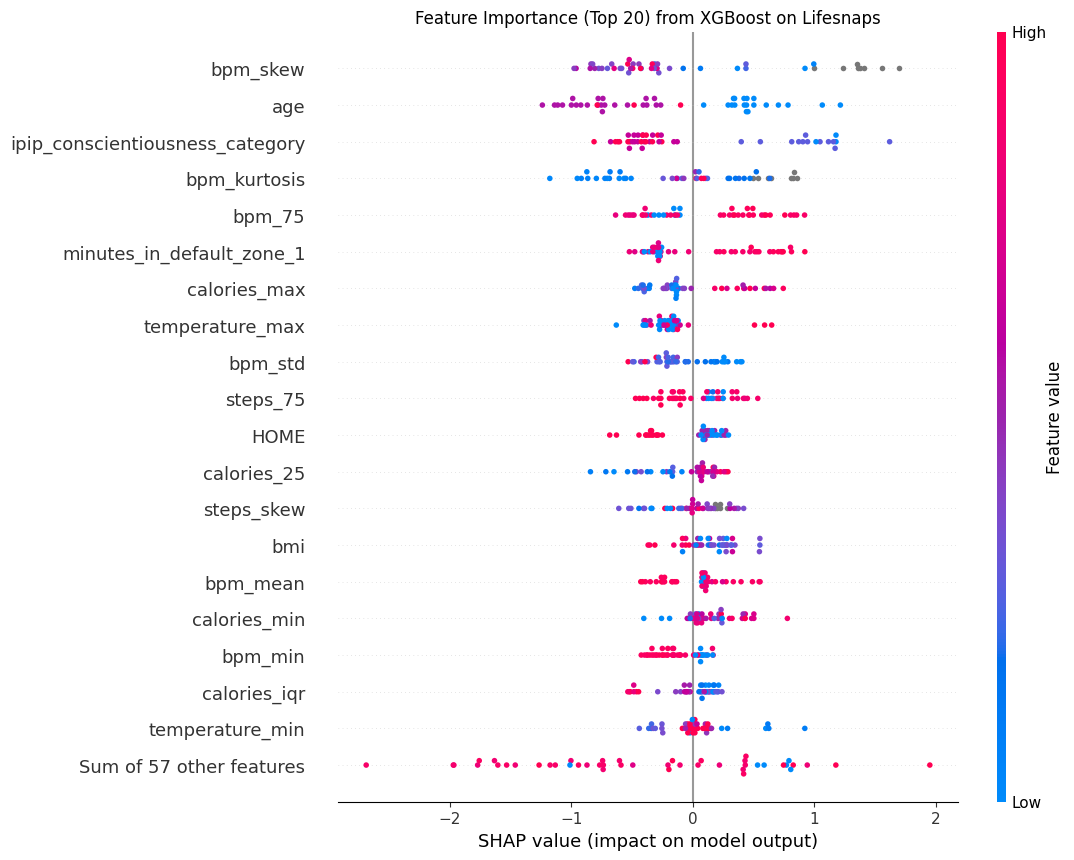

In [44]:
# Interpret by using SHAP show 20 features with highest SHAP values, show the bar plot, vertical bar plot
import shap
import matplotlib.pyplot as plt
explainer = shap.Explainer(clf)
explanation = explainer(x_eval)

fig, ax = plt.subplots(figsize=(10, 10))
ax = shap.plots.beeswarm(explanation, max_display=20, show=False)
ax.set_title('Feature Importance (Top 20) from XGBoost on Lifesnaps')
fig.set_size_inches(10, 10)
# save the fig as png
fig.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
fig.savefig('shap_beeswarm.pdf', dpi=300, bbox_inches='tight')

In [45]:
x_train, y_train = get_pmdata_stats(
    flag='train', norm_type='quantile_global', fold=fold,
)
x_eval, y_eval = get_pmdata_stats(
    flag='test', norm_type='quantile_global', fold=fold,
)
x_train = x_train[y_train != -1]
y_train = y_train[y_train != -1]
x_eval = x_eval[y_eval != -1]
y_eval = y_eval[y_eval != -1]

clf = XGBClassifier(seed=seed)
clf.fit(x_train, y_train)
yhat_eval = clf.predict(x_eval)
acc = accuracy_score(y_eval, yhat_eval)
auc = roc_auc_score(y_eval, yhat_eval)
print(acc, auc)

0.8776978417266187 0.7192054058454774


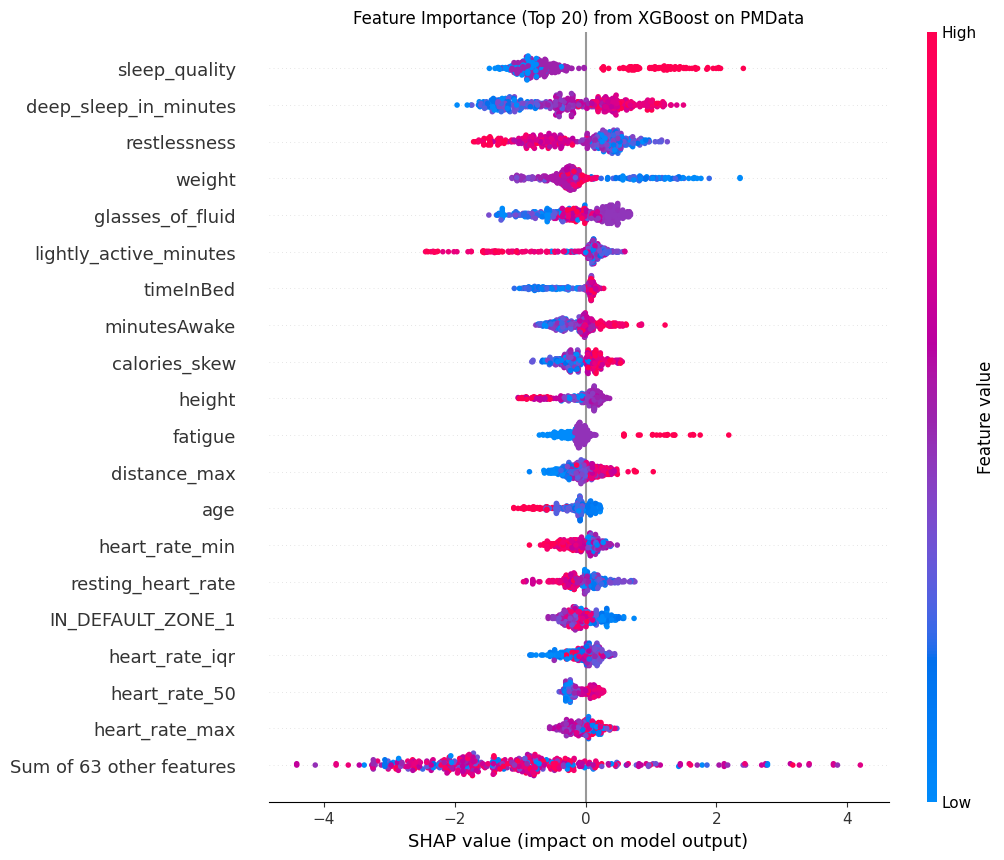

In [46]:
explainer = shap.Explainer(clf)
explanation = explainer(x_eval)

fig, ax = plt.subplots(figsize=(10, 10))
ax = shap.plots.beeswarm(explanation, max_display=20, show=False)
ax.set_title('Feature Importance (Top 20) from XGBoost on PMData')
fig.set_size_inches(10, 10)
# save the fig as png
fig.savefig('pmdata.png', dpi=300, bbox_inches='tight')
fig.savefig('pmdata.pdf', dpi=300, bbox_inches='tight')